In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import shap

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

csv_path = "fake_job_postings.csv"

if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Dataset 'fake_job_postings.csv' not found. Please upload it:")
        uploaded = files.upload()
    except ImportError:
        print(f"Local file '{csv_path}' not found. Please place it in the same directory.")
else:
    print(f"Dataset found at '{csv_path}'. Skipping upload prompt.")

Using device: cuda
Dataset found at 'fake_job_postings.csv'. Skipping upload prompt.


In [2]:
df = pd.read_csv(csv_path)
df.fillna(" ", inplace=True)
df['combined_text'] = df['title'] + " " + df['company_profile'] + " " + df['description'] + " " + df['requirements'] + " " + df['benefits']

train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['fraudulent'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df['fraudulent'], random_state=42)

class BERTDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.labels = df['fraudulent'].values
        self.texts = df['combined_text'].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

In [3]:
class BERT_BiLSTM(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", lstm_hidden_dim=128, output_dim=1, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        transformer_hidden_dim = self.transformer.config.hidden_size

        if freeze_bert:
            for param in self.transformer.parameters():
                param.requires_grad = False

        self.lstm = nn.LSTM(
            transformer_hidden_dim,
            lstm_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, input_ids, attention_mask):
        with torch.set_grad_enabled(self.transformer.training and any(p.requires_grad for p in self.transformer.parameters())):
            outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state

        lstm_out, _ = self.lstm(last_hidden_state)
        pooled, _ = torch.max(lstm_out, dim=1)
        logits = self.fc(pooled)
        return logits.squeeze(1)

In [4]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
train_dataset = BERTDataset(train_df, tokenizer)
val_dataset = BERTDataset(val_df, tokenizer)
test_dataset = BERTDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = BERT_BiLSTM(freeze_bert=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)

# Moderate weight balancing to optimize both Precision and Recall
pos_weight = torch.tensor([2.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

best_f1 = 0.0
epochs = 3

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validate
    model.eval()
    val_probs = []
    val_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']

            outputs = torch.sigmoid(model(input_ids, attention_mask))
            val_probs.extend(outputs.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_labels_int = [int(l) for l in val_labels]
    val_preds = (np.array(val_probs) >= 0.5).astype(int)
    report = classification_report(val_labels_int, val_preds, output_dict=True, zero_division=0)
    val_f1 = report.get('1', report.get('1.0', report.get(1, {}))).get('f1-score', 0.0)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "bert_bilstm_best.pt")
        print("  Saved new best proposed model checkpoint!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | Loss: 0.2821 | Val F1: 0.2062
  Saved new best proposed model checkpoint!
Epoch 2/3 | Loss: 0.1788 | Val F1: 0.7262
  Saved new best proposed model checkpoint!
Epoch 3/3 | Loss: 0.1293 | Val F1: 0.7719
  Saved new best proposed model checkpoint!


Proposed BERT-BiLSTM Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3403
         1.0       0.80      0.74      0.77       173

    accuracy                           0.98      3576
   macro avg       0.89      0.87      0.88      3576
weighted avg       0.98      0.98      0.98      3576



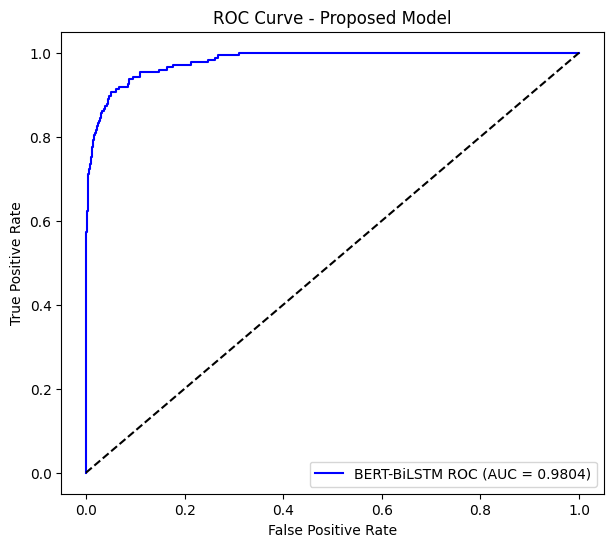

In [5]:
model.load_state_dict(torch.load("bert_bilstm_best.pt"))
model.eval()

test_probs = []
test_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']

        outputs = torch.sigmoid(model(input_ids, attention_mask))
        test_probs.extend(outputs.cpu().numpy())
        test_labels.extend(labels.numpy())

test_preds = (np.array(test_probs) >= 0.5).astype(int)
print("Proposed BERT-BiLSTM Classification Report:")
print(classification_report(test_labels, test_preds))

# Format and print explicit publication-ready performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc = accuracy_score(test_labels, test_preds)
prec = precision_score(test_labels, test_preds)
rec = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
auc_val = roc_auc_score(test_labels, test_probs)

print("\n--- Final Performance Metrics Summary ---")
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print(f"ROC-AUC:   {auc_val*100:.2f}%")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'BERT-BiLSTM ROC (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Proposed Model')
plt.legend(loc='lower right')
plt.show()

In [6]:
print("Running SHAP Token Attribution...")

def predict_fn(texts):
    inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(inputs['input_ids'], inputs['attention_mask'])
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

# Use small subsets for explainer
background_texts = test_df['combined_text'].values[:15]
test_samples = test_df['combined_text'].values[100:102]

explainer = shap.Explainer(predict_fn, tokenizer)
shap_values = explainer(test_samples)

# Plot text attribution for first sample
shap.plots.text(shap_values[0])

Running SHAP Token Attribution...
